In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 20
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

In [3]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

def plot_activity_helper(activity, n, m, channel_idx, cmap='viridis'):
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity).item()
    vmax = torch.max(activity).item()
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step+1}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idxs,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    activity = torch.clamp(activity, max=2)
    plot_activity_helper(torch.mean(activity, axis=1), n, m, "all", cmap)
    
    if channel_idxs is None:
        channel_idxs = np.arange(activity.shape[1])
        
    for channel_idx in channel_idxs:
        channel_activity = activity[:, channel_idx]
        plot_activity_helper(channel_activity, n, m, channel_idx, cmap)

def plot(sample_indices,ablater=None):
    # Main plotting loop
    for plot_idx, sample_idx in enumerate(sample_indices):
        inp, label = inputs[sample_idx], labels[sample_idx]
        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
        activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                .detach().cpu()[0]  # shape (T, C)

        plot_channel_activity_solo(activity, channels_to_plot, n, m)

In [4]:
# ——— User‐set paths & names ———
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    # also used as epoch

# ReLU
wandb_name = "earnest-planet-436"
checkpoint = 800

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)
classifier.eval()

# ——— Plot settings ———
excitatory = True
n, m = 4, 5  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = [] #None #[0, 1, 2, 3] 
sample_indices = [0, 1, 2, 3, 4, 5]
do_highlight_self_kernel = False

/tmp/ipykernel_3955002/124203490.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

In [120]:
np.arange(0, 30, 5)

array([ 0,  5, 10, 15, 20, 25])

In [119]:
classifier.to(device)
classifier.eval()
accuracies = []
num_steps_to_try = [0, 5, 10, 15, 16, 17, 18, 18, 20, 21, 22, 25]

for num_steps in num_steps_to_try:
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, labels in tqdm(test_loader):
            x = x.to(device)
            labels = labels.to(device)
            
            logits = classifier(x, num_steps=20)
            
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(accuracy)
    accuracies.append(accuracy)

100%|██████████| 3456/3456 [01:47<00:00, 32.29it/s]

0.9914496527777777


In [48]:
def cell_to_pixels(r, c):
    """Map a logical cell (r,c) to the 2×2 pixel block in a 48×48 grid."""
    return [(2*r + dr, 2*c + dc) for dr in (0, 1) for dc in (0, 1)]

def left():
    # horizontal line at logical row 12, for columns 0–11
    return [pix for j in range(12) for pix in cell_to_pixels(12, j)]

def right():
    # horizontal line at logical row 12, for columns 12–23
    return [pix for j in range(12, 24) for pix in cell_to_pixels(12, j)]

def up():
    # vertical line at logical col 12, for rows 0–11
    return [pix for i in range(12) for pix in cell_to_pixels(i, 12)]

def down():
    # vertical line at logical col 12, for rows 12–23
    return [pix for i in range(12, 24) for pix in cell_to_pixels(i, 12)]

def diagonal_zigzag(d1, d2, start=(12, 12), repeats=11):
    """
    Walk a zig-zag path of 2 steps in d1 then 2 steps in d2, repeating.
    d1, d2: direction tuples, e.g. (0,1) then (1,0) for down_right
    """
    moves = ([d1]*2 + [d2]*2) * repeats
    r, c = start
    path = [(r, c)]
    for dr, dc in moves:
        r, c = r + dr, c + dc
        if not (0 <= r < 24 and 0 <= c < 24):
            break
        path.append((r, c))
    # expand each logical cell into its 2×2 pixels
    return [pix for cell in path for pix in cell_to_pixels(*cell)]

def down_right():
    return diagonal_zigzag((0, 1), (1, 0))

def down_left():
    return diagonal_zigzag((0, -1), (1, 0))

def up_right():
    return diagonal_zigzag((0, 1), (-1, 0))

def up_left():
    return diagonal_zigzag((0, -1), (-1, 0))

def _base_u(cells=24, horiz=8, vert=4):
    """
    Build a 24×24 U‐maze open to the left, centered, with:
      - horizontal arms of length horiz+1
      - vertical connector of span vert+1
    """
    M = np.zeros((cells, cells), dtype=int)
    # top‐arm row
    r0 = (cells - vert) // 2
    # leftmost column of arms
    c0 = (cells - horiz) // 2

    # draw the two horizontal legs
    M[r0,        c0 : c0 + horiz + 1] = 1
    M[r0 + vert, c0 : c0 + horiz + 1] = 1
    # draw the vertical connector
    M[r0 : r0 + vert + 1, c0 + horiz] = 1

    return M

def _logical_endpoints(base):
    """
    Find logical cells in `base` with exactly one 4-neighbor—these are the U-ends.
    """
    endpoints = []
    H, W = base.shape
    for r, c in zip(*np.where(base == 1)):
        # count 4-neighbors
        cnt = sum(
            0 <= r+dr < H and 0 <= c+dc < W and base[r+dr, c+dc] == 1
            for dr, dc in ((1,0),(-1,0),(0,1),(0,-1))
        )
        if cnt == 1:
            endpoints.append((r, c))
    return endpoints

def _expand(base):
    """
    Given a 24×24 logical `base`, returns two lists of pixels in 48×48:
     - all wall pixels
     - endpoint pixels
    """
    wall_cells = list(zip(*np.where(base == 1)))
    end_cells  = _logical_endpoints(base)

    wall_pixels     = [pix for cell in wall_cells    for pix in cell_to_pixels(*cell)]
    endpoint_pixels = [pix for cell in end_cells     for pix in cell_to_pixels(*cell)]
    return wall_pixels, endpoint_pixels

def maze_right(arm=12, vert=4):
    base = _base_u(24, arm, vert)
    return _expand(base)

def maze_left(arm=12, vert=4):
    base = np.fliplr(_base_u(24, arm, vert))
    return _expand(base)

def maze_up(arm=12, vert=4):
    base = np.rot90(_base_u(24, arm, vert), k=1)
    return _expand(base)

def maze_down(arm=12, vert=4):
    base = np.rot90(_base_u(24, arm, vert), k=-1)
    return _expand(base)

custom_input = np.array([  
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

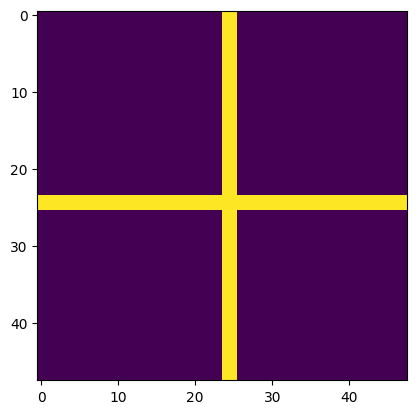

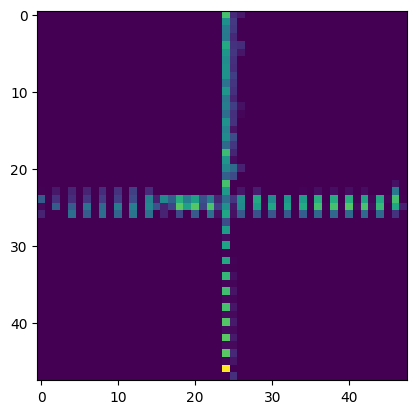

In [6]:
neuron_ablation_config = {
    0:
    {
        # 0: "zero",
        # 1: "zero",
        # 2: "zero",
        6: "zero"
    }
}

ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}

base_input = np.array([  
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

walls = base_input.copy()
corridor_idx = 12
walls[corridor_idx, :] = 1
walls[:, corridor_idx] = 1
walls = walls.repeat(2, axis=0).repeat(2, axis=1)
walls = np.stack([walls, walls, walls], axis=0)   # shape (3, 48, 48)

points = base_input.copy()
points[12, 8] = 1
points = points.repeat(2, axis=0).repeat(2, axis=1)
points = points[np.newaxis, ...]
inp = np.concatenate([walls, points], axis=0)
inp = torch.tensor(inp, dtype=torch.float32)
plt.imshow(inp[0])
plt.show()
# plt.imshow(inp[3])
# plt.show()

# ablater=None
# _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
# activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
#         .detach().cpu()[0]  # shape (T, C)
# plot_channel_activity_solo(activity, channels_to_plot, n, m)

# for i in range(7):
#     neuron_ablation_config = {0: {i: "zero"}}
#     ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}
#     _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
#     activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
#             .detach().cpu()[0]  # shape (T, C)

#     plot_channel_activity_solo(activity, channels_to_plot, n, m)

ablater=None
_, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
        .detach().cpu()[0]  # shape (T, C)
plt.imshow(torch.mean(activity[-1], axis=0))
plt.show()

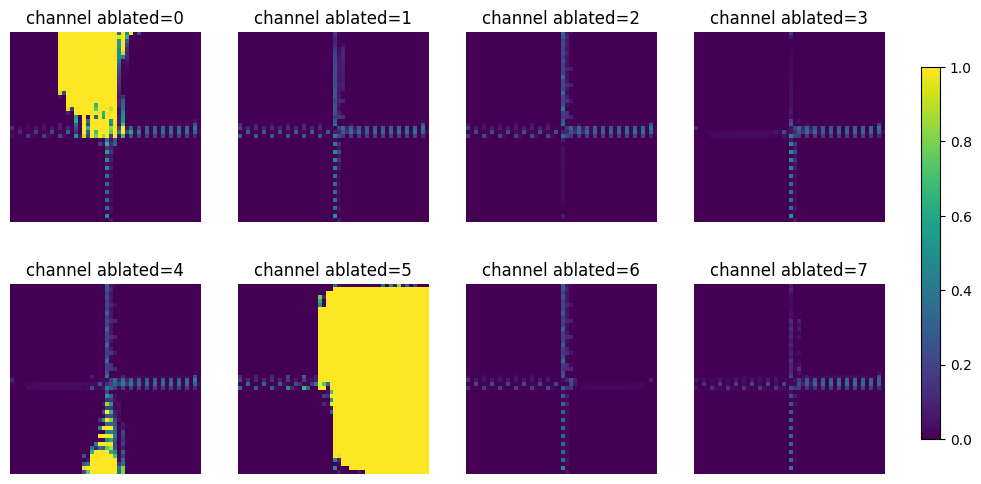

In [180]:
# 1) collect all activity maps
activities = []
for i in range(8):
    neuron_ablation_config = {0: {i: "zero"}}
    ablater = {
        step: {0: Ablation(neuron_ablation_config=neuron_ablation_config)}
        for step in range(num_steps)
    }
    _, neuron_states, _ = model(
        inp.unsqueeze(0),
        num_steps=num_steps,
        ablater=ablater
    )
    activity = model.query_neuron_states(
        neuron_states,
        0,
        0 if excitatory else 1
    ).detach().cpu()[0]   # shape (T, C)
    activity = torch.mean(activity[-1], dim=0)
    activity = torch.clamp(activity, max=1)
    activities.append(activity.numpy())

# 2) compute global vmin/vmax
all_vals = np.concatenate([a.ravel() for a in activities])
vmin, vmax = all_vals.min(), all_vals.max()

# 3) plot grid with shared dynamic limits
n = len(activities)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols*3, nrows*3),
                         squeeze=False)

for idx, ax in enumerate(axes.flat):
    if idx < n:
        im = ax.imshow(activities[idx],
                       vmin=vmin, vmax=vmax,
                       aspect='equal')
        ax.set_title(f'channel ablated={idx}')
    ax.axis('off')

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
plt.show()

# Checking if activity propagates all the way

In [ ]:
points = base_input.copy()
points[12, 12] = 1

points = points.repeat(2, axis=0).repeat(2, axis=1)
points = points[np.newaxis, ...]

threshold = 0.1

prop_directions = {i:[] for i in range(8)}

for i in range(8):
    neuron_ablation_config = {0: {i: "zero"}}
    ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}

    for fn in (left, right, up, down, down_right, down_left, up_right, up_left):
        rows, cols = zip(*fn())
        walls = base_input.copy()
        walls = walls.repeat(2, axis=0).repeat(2, axis=1)
        walls[rows, cols] = 1
        walls = np.stack([walls, walls, walls], axis=0)
        inp = np.concatenate([walls, points], axis=0)
        inp = torch.tensor(inp, dtype=torch.float32)

        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
        activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                .detach().cpu()[0]  # shape (T, C)
        
        # plot_channel_activity_solo(activity, channels_to_plot, n, m)
        mean_activity = torch.mean(activity, axis=1)

        #cut out center
        mean_activity[:, 18:30, 18:30] = 0
        activity_change = (mean_activity[5:] > threshold).sum(dim=(1, 2)).max().item() - (mean_activity[1] > threshold).sum().item()
        if activity_change < 2:
            prop_directions[i].append(fn.__name__)
    

# Checking if mazes can be solved

In [102]:
def plot_jawn(arm, vert, ablation_channel, fn, num_steps):
    neuron_ablation_config = {0: {ablation_channel: "zero"}}
    ablater = {j:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for j in range(num_steps)}

    # predesigned input
    wall_pixels, input_pixels = fn(arm=arm, vert=vert)
    wall_rows, wall_cols = zip(*wall_pixels)
    input_rows, input_cols = zip(*input_pixels)
    walls = base_input.copy()
    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls[wall_rows, wall_cols] = 1
    walls = np.stack([walls, walls, walls], axis=0)
    points = base_input.copy()
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points[input_rows, input_cols] = 1
    points = points[np.newaxis, ...]

    #combine
    inp = np.concatenate([walls, points], axis=0)
    inp = torch.tensor(inp, dtype=torch.float32)

    pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=20, ablater=ablater, return_activations=True)

    correct = (pred.argmax(dim=1).item() == 1)
    print(correct)
    if not correct:
        prop_directions[i].append(fn.__name__)
    
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # shape (T, C)
    plot_channel_activity_solo(activity, channels_to_plot, n, m)


In [116]:
taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]

In [112]:
taus

array([1.       , 1.0015665, 1.       , 1.0026691, 1.       , 1.       ,
       1.0046306, 2.2004402], dtype=float32)

Text(0, 0.5, 'tau')

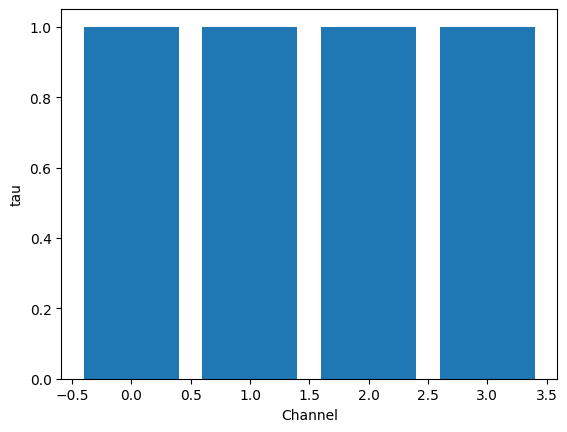

In [118]:
plt.bar(np.arange(4), taus)
plt.xlabel("Channel")
plt.ylabel("tau")

False


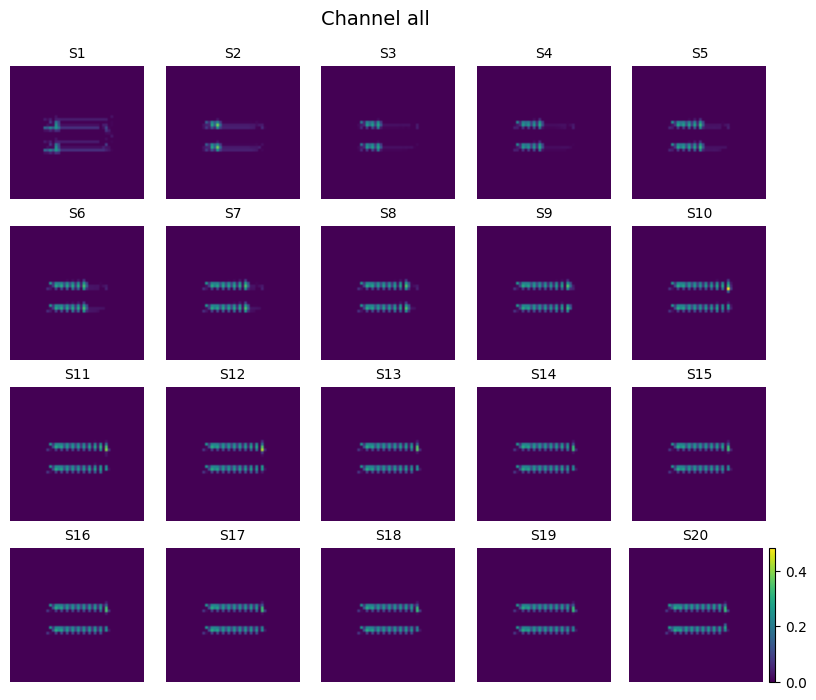

In [104]:
plot_jawn(10, 4, 3, maze_right, num_steps)

In [113]:
threshold = 0.1

arm = 12
vert = 8

for arm in [10]:
    for vert in [4]:
        prop_directions = {i:[] for i in range(8)}

        for i in range(9):
            if i == 0:
                ablater = None
            else:
                i = i - 1
                neuron_ablation_config = {0: {i: "zero"}}
                ablater = {j:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for j in range(num_steps)}

            for fn in (maze_left, maze_right, maze_up, maze_down):

                print(i, fn.__name__)

                # predesigned input
                wall_pixels, input_pixels = fn(arm=arm, vert=vert)
                wall_rows, wall_cols = zip(*wall_pixels)
                input_rows, input_cols = zip(*input_pixels)
                walls = base_input.copy()
                walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                walls[wall_rows, wall_cols] = 1
                walls = np.stack([walls, walls, walls], axis=0)
                points = base_input.copy()
                points = points.repeat(2, axis=0).repeat(2, axis=1)
                points[input_rows, input_cols] = 1
                points = points[np.newaxis, ...]

                # custom input
                # walls = custom_input.copy()
                # point_idxs = _logical_endpoints(walls)
                # walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                # walls = np.stack([walls, walls, walls], axis=0)
                # points = base_input.copy()
                # for (row, col) in point_idxs:
                #     points[row, col] = 1
                # points = points.repeat(2, axis=0).repeat(2, axis=1)
                # points = points[np.newaxis, ...]

                #combine
                inp = np.concatenate([walls, points], axis=0)
                inp = torch.tensor(inp, dtype=torch.float32)

                # _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
                # activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                #         .detach().cpu()[0]  # shape (T, C)
                # plot_channel_activity_solo(activity, channels_to_plot, n, m)

                pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=20, ablater=ablater, return_activations=True)

                correct = (pred.argmax(dim=1).item() == 1)
                print(correct)
                if not correct:
                    prop_directions[i].append(fn.__name__)
                
                # activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # shape (T, C)
                # plot_channel_activity_solo(activity, channels_to_plot, n, m)

        print(arm, vert) 
        print(prop_directions)
        
# {0: [], 1: [], 2: ['maze_down'], 3: [], 4: [], 5: [], 6: [], 7: ['maze_up']}
# {0: [], 1: [], 2: ['maze_down'], 3: ['maze_left', 'maze_up'], 4: ['maze_left'], 5: [], 6: ['maze_right'], 7: ['maze_up']}



0 maze_left
True
0 maze_right
True
0 maze_up
True
0 maze_down
True
0 maze_left
True
0 maze_right
True
0 maze_up
True
0 maze_down
True
1 maze_left
True
1 maze_right
True
1 maze_up
True
1 maze_down
True
2 maze_left
True
2 maze_right
True
2 maze_up
True
2 maze_down
False
3 maze_left
True
3 maze_right
True
3 maze_up
True
3 maze_down
True
4 maze_left
True
4 maze_right
True
4 maze_up
True
4 maze_down
True
5 maze_left
True
5 maze_right
True
5 maze_up
True
5 maze_down
True
6 maze_left
True
6 maze_right
True
6 maze_up
True
6 maze_down
True
7 maze_left
True
7 maze_right
True
7 maze_up
False
7 maze_down
True
10 4
{0: [], 1: [], 2: ['maze_down'], 3: [], 4: [], 5: [], 6: [], 7: ['maze_up']}


In [59]:
prop_directions

{0: [], 1: [], 2: ['maze_down'], 3: [], 4: [], 5: [], 6: [], 7: ['maze_up']}

In [256]:
prop_directions

{0: [],
 1: ['maze_up'],
 2: ['maze_down'],
 3: ['maze_left'],
 4: ['maze_left'],
 5: [],
 6: ['maze_up', 'maze_down'],
 7: ['maze_left', 'maze_up']}